# Tabular model evaluation

This notebook evaluates the frozen outputs of `scripts/16_train_baseline_models.py`. Model-family selection and the subsequent small XGBoost search use validation MAE only. The selected specification is then refitted on training plus validation data and evaluated on the fixed test sample; test results do not enter tuning or selection.

It examines:

1. validation performance, tuning, and learning curves;
2. aggregate and quarterly test performance;
3. comparison with a no-information predictive benchmark;
4. prediction calibration and Fragility Score ordering; and
5. residual and tail-error diagnostics.

The notebook reads saved outputs only. It does not retrain or select a model.

## 1. Setup and saved outputs

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter
import numpy as np
import pandas as pd
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


project_root = Path.cwd().resolve()

while not (project_root / 'config' / 'paths.yaml').is_file():
    if project_root.parent == project_root:
        raise FileNotFoundError('Could not locate the project root.')
    project_root = project_root.parent

if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from src.utils.configuration import get_paths_config
from src.visualization.style import (
    COLOR_PALETTE,
    SINGLE_PANEL_SIZE,
    TWO_PANEL_SIZE,
    apply_matplotlib_layout,
    set_matplotlib_style,
)


paths = get_paths_config()
results_directory = paths.tables / 'modeling'
validation_path = results_directory / 'baseline_validation_performance.csv'
tuning_path = results_directory / 'baseline_tuning_performance.csv'
tuning_history_path = results_directory / 'baseline_tuning_history.csv'
test_path = results_directory / 'selected_baseline_test_performance.csv'
benchmark_path = results_directory / 'predictive_benchmark_performance.csv'
predictions_path = (
    results_directory / 'selected_baseline_test_predictions.parquet'
)

for description, path in {
    'validation performance': validation_path,
    'tuning performance': tuning_path,
    'tuning history': tuning_history_path,
    'test performance': test_path,
    'predictive benchmarks': benchmark_path,
    'test predictions': predictions_path,
}.items():
    if not path.is_file():
        raise FileNotFoundError(f'{description} not found: {path}')

validation = pd.read_csv(validation_path)
tuning = pd.read_csv(tuning_path)
tuning_history = pd.read_csv(tuning_history_path)
test_performance = pd.read_csv(test_path)
benchmarks = pd.read_csv(benchmark_path)
predictions = pd.read_parquet(predictions_path)
target = 'future_max_drawdown_63d'
prediction = 'predicted_future_max_drawdown_63d'
selected_model = validation.loc[validation['selected'], 'model'].item()
test_benchmark = benchmarks.loc[benchmarks['sample_split'].eq('test')].copy()

if test_performance['model'].item() != selected_model:
    raise RuntimeError('Validation and test outputs identify different models.')
if tuning['selected'].sum() != 1 or not tuning.loc[tuning['mae'].idxmin(), 'selected']:
    raise RuntimeError('The tuning output does not identify the lowest-MAE candidate.')
if tuple(tuning_history.columns) != ('boosting_round', 'training_mae', 'validation_mae'):
    raise RuntimeError('The selected-model tuning history is invalid.')
if len(test_benchmark) != 1 or test_benchmark['model'].item() != 'naive_mean':
    raise RuntimeError('The test benchmark is missing or invalid.')
if predictions.duplicated(['report_period', 'permno']).any():
    raise RuntimeError('Test predictions contain duplicate stock-quarter rows.')
if predictions[[target, prediction, 'fragility_score']].isna().any().any():
    raise RuntimeError('Test predictions contain missing values.')
if not predictions[target].between(0, 1).all():
    raise RuntimeError('Test targets must lie within [0, 1].')
if not predictions[prediction].between(0, 1).all():
    raise RuntimeError('Test predictions must lie within [0, 1].')
if not predictions['fragility_score'].between(0, 100).all():
    raise RuntimeError('Fragility Scores must lie within [0, 100].')

set_matplotlib_style()

print(f'Selected model: {selected_model}')
print(f'Validation models: {len(validation):,}')
print(f'Test observations: {len(predictions):,}')
print(f'Test quarters: {predictions["report_period"].nunique():,}')

Selected model: xgboost_augmented
Validation models: 5
Test observations: 30,511
Test quarters: 8


## 2. Validation comparison and tuning

The frozen selection criterion is the lowest validation MAE. The original model is retained in the tuning table, and all 12 alternatives use the same market features. Other metrics provide context but do not alter the selection rule. The final graph reports training and validation MAE across boosting rounds for the selected tuning candidate; the test sample is not used.

,model,feature_group,observations,quarters,mae,rmse,r2,mean_quarterly_spearman,selected
0,xgboost_augmented,augmented,"29,716",7,0.0942,0.1305,0.475,0.750,True
1,xgboost_market,market,"29,716",7,0.0954,0.1320,0.463,0.748,False
2,ridge_augmented,augmented,"29,716",7,0.0956,0.1334,0.452,0.746,False
3,ridge_market,market,"29,716",7,0.0959,0.1337,0.449,0.747,False
4,naive_mean,none,"29,716",7,0.1347,0.1871,-0.078,—,False


Selected validation MAE: 0.094249
Next-best validation MAE: 0.095373
Absolute selection margin: 0.001124


,candidate,n_estimators,max_depth,min_child_weight,subsample,mae,rmse,r2,mean_quarterly_spearman,selected
0,candidate_07,179,3,5,0.800000,0.094249,0.130522,0.475,0.750,True
1,candidate_05,175,3,1,0.800000,0.094273,0.130510,0.475,0.751,False
2,candidate_04,271,2,5,1.000000,0.094344,0.130598,0.474,0.750,False
3,candidate_02,243,2,1,1.000000,0.094345,0.130582,0.475,0.750,False
4,candidate_08,160,3,5,1.000000,0.094584,0.130697,0.474,0.750,False
5,candidate_01,197,2,1,0.800000,0.094605,0.130636,0.474,0.750,False
6,candidate_03,197,2,5,0.800000,0.094605,0.130636,0.474,0.750,False
7,candidate_06,194,3,1,1.000000,0.094648,0.130777,0.473,0.750,False
8,candidate_11,107,4,5,0.800000,0.094736,0.130779,0.473,0.750,False
9,candidate_10,108,4,1,1.000000,0.094776,0.130777,0.473,0.750,False


Validation MAE improvement over untuned model: 0.000651 (0.69%)
Selected parameters: 179 trees, depth 3, minimum child weight 5, subsample 0.8


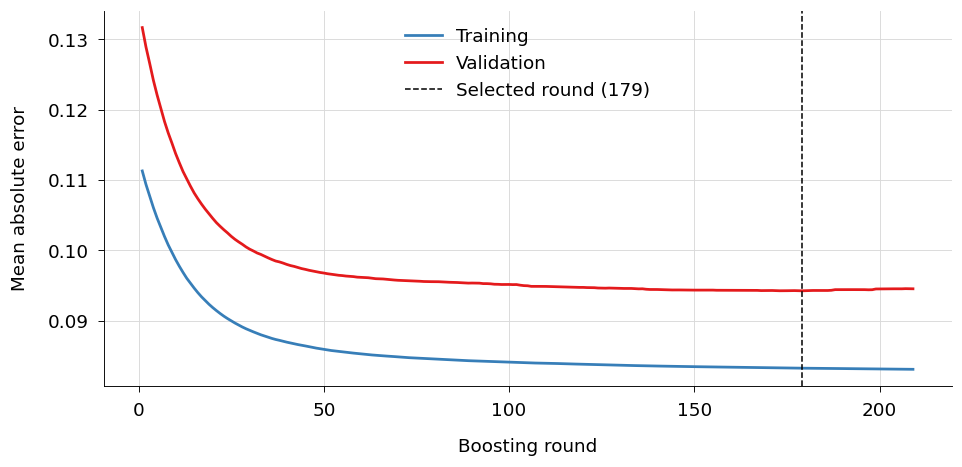

In [2]:
validation_display = validation.sort_values('mae').reset_index(drop=True)
validation_table = validation_display[
    [
        'model',
        'feature_group',
        'mae',
        'rmse',
        'r2',
        'mean_quarterly_spearman',
    ]
].rename(
    columns={
        'model': 'Model',
        'feature_group': 'Feature set',
        'mae': 'MAE',
        'rmse': 'RMSE',
        'r2': 'R2',
        'mean_quarterly_spearman': 'Spearman',
    }
)
validation_table.to_latex(
    paths.tables / '04_01_baseline_validation_performance.tex',
    index=False,
    na_rep='---',
    escape=True,
    formatters={
        'MAE': '{:.4f}'.format,
        'RMSE': '{:.4f}'.format,
        'R2': '{:.3f}'.format,
        'Spearman': lambda value: '---' if pd.isna(value) else f'{value:.3f}',
    },
)
display(
    validation_display.style.format(
        {
            'observations': '{:,}',
            'quarters': '{:,}',
            'mae': '{:.4f}',
            'rmse': '{:.4f}',
            'r2': '{:.3f}',
            'mean_quarterly_spearman': '{:.3f}',
        },
        na_rep='—',
    )
)

selection_margin = (
    validation_display.loc[1, 'mae']
    - validation_display.loc[0, 'mae']
)
print(f'Selected validation MAE: {validation_display.loc[0, "mae"]:.6f}')
print(f'Next-best validation MAE: {validation_display.loc[1, "mae"]:.6f}')
print(f'Absolute selection margin: {selection_margin:.6f}')

tuning_display = tuning.sort_values('mae').reset_index(drop=True)
display(
    tuning_display.style.format(
        {
            'n_estimators': '{:,}',
            'mae': '{:.6f}',
            'rmse': '{:.6f}',
            'r2': '{:.3f}',
            'mean_quarterly_spearman': '{:.3f}',
        }
    )
)
untuned_mae = tuning.loc[tuning['candidate'].eq('untuned'), 'mae'].item()
tuned_mae = tuning.loc[tuning['selected'], 'mae'].item()
selected_tuning = tuning.loc[tuning['selected']].iloc[0]
print(
    'Validation MAE improvement over untuned model: '
    f'{untuned_mae - tuned_mae:.6f} '
    f'({(untuned_mae / tuned_mae - 1):.2%})'
)
print(
    'Selected parameters: '
    f"{int(selected_tuning['n_estimators'])} trees, "
    f"depth {int(selected_tuning['max_depth'])}, "
    f"minimum child weight {int(selected_tuning['min_child_weight'])}, "
    f"subsample {selected_tuning['subsample']:.1f}"
)

selected_round = int(selected_tuning['n_estimators'])
figure, axis = plt.subplots(figsize=SINGLE_PANEL_SIZE)
axis.plot(
    tuning_history['boosting_round'],
    tuning_history['training_mae'],
    color=COLOR_PALETTE[0],
    label='Training',
)
axis.plot(
    tuning_history['boosting_round'],
    tuning_history['validation_mae'],
    color=COLOR_PALETTE[1],
    label='Validation',
)
axis.axvline(
    selected_round,
    color='black',
    linestyle='--',
    linewidth=1,
    label=f'Selected round ({selected_round})',
)
axis.set_xlabel('Boosting round')
axis.set_ylabel('Mean absolute error')
axis.legend()
apply_matplotlib_layout(figure)
figure.savefig(paths.figures / "04_01_selected_model_learning_curves.pdf")
plt.show()

## 3. Held-out test performance

Aggregate metrics summarize prediction error and cross-sectional ordering. The historical-mean forecast is the no-information magnitude benchmark; zero Spearman correlation represents random stock ordering. Quarterly results show whether performance is concentrated in only a few test periods.

,model,observations,quarters,mae,rmse,r2,mean_quarterly_spearman
0,naive_mean,"30,511",8,0.1302,0.1819,-0.053,nan
1,xgboost_market_same_specification,"30,511",8,0.0912,0.1258,0.497,0.738
2,xgboost_augmented,"30,511",8,0.0904,0.1249,0.504,0.739


,report_period,model,observations,mae,rmse,r2,spearman
0,2024-03-31 00:00:00,XGBoost market,"4,005",0.0825,0.1218,0.568,0.802
1,2024-06-30 00:00:00,XGBoost market,"3,946",0.0871,0.1173,0.521,0.764
2,2024-09-30 00:00:00,XGBoost market,"3,869",0.0826,0.1220,0.511,0.730
3,2024-12-31 00:00:00,XGBoost market,"3,819",0.1197,0.1559,0.242,0.729
4,2025-03-31 00:00:00,XGBoost market,"3,767",0.0946,0.1206,0.433,0.720
5,2025-06-30 00:00:00,XGBoost market,"3,733",0.0835,0.1164,0.511,0.716
6,2025-09-30 00:00:00,XGBoost market,"3,706",0.0946,0.1285,0.540,0.747
7,2025-12-31 00:00:00,XGBoost market,"3,666",0.0852,0.1192,0.474,0.698
8,2024-03-31 00:00:00,XGBoost augmented,"4,005",0.0821,0.1213,0.572,0.803
9,2024-06-30 00:00:00,XGBoost augmented,"3,946",0.0864,0.1167,0.526,0.765


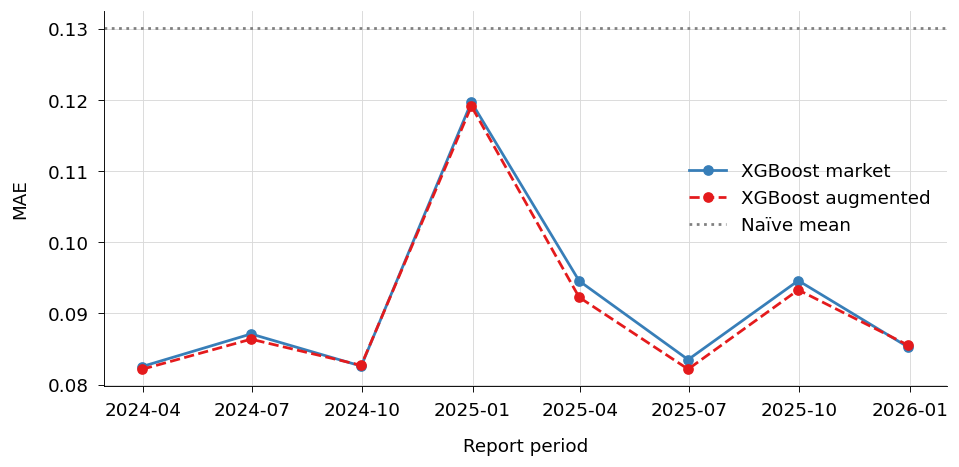

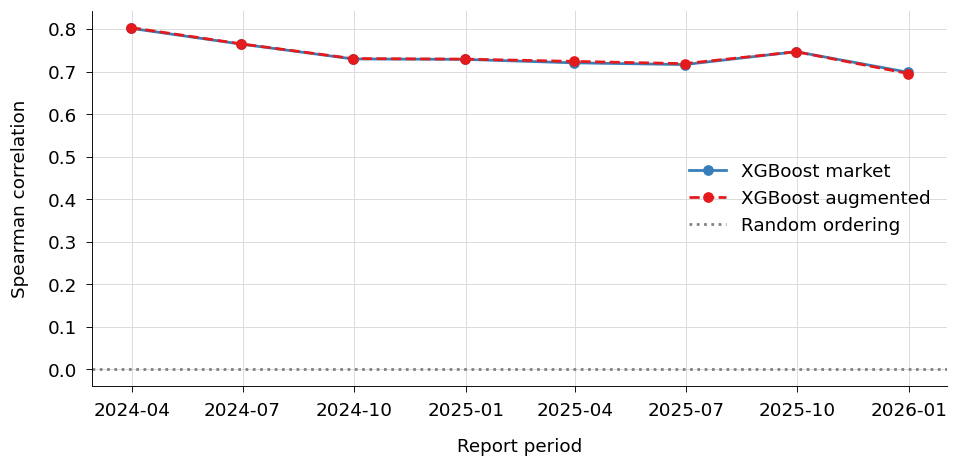

In [3]:
import joblib
from xgboost import XGBRegressor

from src.modeling.feature_sets import MARKET_FEATURES

model_path = paths.models / 'baseline' / 'selected_baseline_model.joblib'
sample_path = paths.processed / 'modeling' / 'modeling_sample.parquet'

selected_bundle = joblib.load(model_path)
market_features = list(MARKET_FEATURES)

sample = pd.read_parquet(
    sample_path,
    columns=[
        'report_period',
        'sample_split',
        target,
        *market_features,
    ],
)

fitting_sample = sample.loc[
    sample['sample_split'].isin(['train', 'validation'])
].copy()
market_test = sample.loc[
    sample['sample_split'].eq('test')
].copy()

# Apply the same fitting-sample preprocessing used by the selected model.
def transform_market_features(frame):
    transformed = frame[market_features].astype(float).copy()

    transformed['market_cap_usd'] = np.log1p(
        transformed['market_cap_usd']
    )

    preprocessing = selected_bundle['preprocessing']

    return (
        transformed.clip(
            lower=preprocessing['lower'][market_features],
            upper=preprocessing['upper'][market_features],
            axis='columns',
        )
        .fillna(preprocessing['medians'][market_features])
        .to_numpy()
    )


market_model = XGBRegressor(
    **selected_bundle['model'].get_params()
)
market_model.fit(
    transform_market_features(fitting_sample),
    fitting_sample[target],
)

market_test_prediction = np.clip(
    market_model.predict(transform_market_features(market_test)),
    0,
    1,
)
market_test['prediction'] = market_test_prediction


def calculate_performance(model_name, frame, prediction_column):
    quarterly_spearman = (
        frame.groupby('report_period')
        .apply(
            lambda quarter: quarter[target].corr(
                quarter[prediction_column],
                method='spearman',
            ),
            include_groups=False,
        )
    )

    return {
        'model': model_name,
        'observations': len(frame),
        'quarters': frame['report_period'].nunique(),
        'mae': mean_absolute_error(
            frame[target],
            frame[prediction_column],
        ),
        'rmse': mean_squared_error(
            frame[target],
            frame[prediction_column],
        ) ** 0.5,
        'r2': r2_score(
            frame[target],
            frame[prediction_column],
        ),
        'mean_quarterly_spearman': quarterly_spearman.mean(),
    }


market_test_performance = pd.DataFrame(
    [
        calculate_performance(
            'xgboost_market_same_specification',
            market_test,
            'prediction',
        )
    ]
)

test_comparison = pd.concat(
    [
        test_benchmark.assign(mean_quarterly_spearman=np.nan),
        market_test_performance,
        test_performance,
    ],
    ignore_index=True,
)

display(
    test_comparison[
        [
            'model',
            'observations',
            'quarters',
            'mae',
            'rmse',
            'r2',
            'mean_quarterly_spearman',
        ]
    ].style.format(
        {
            'observations': '{:,}',
            'quarters': '{:,}',
            'mae': '{:.4f}',
            'rmse': '{:.4f}',
            'r2': '{:.3f}',
            'mean_quarterly_spearman': '{:.3f}',
        }
    )
)


selected_quarterly = predictions.rename(
    columns={prediction: 'prediction'}
)[['report_period', target, 'prediction']]

quarterly_rows = []

for model_name, frame in {
    'XGBoost market': market_test,
    'XGBoost augmented': selected_quarterly,
}.items():
    for report_period, quarter in frame.groupby(
        'report_period',
        sort=True,
    ):
        quarterly_rows.append(
            {
                'report_period': report_period,
                'model': model_name,
                'observations': len(quarter),
                'mae': mean_absolute_error(
                    quarter[target],
                    quarter['prediction'],
                ),
                'rmse': mean_squared_error(
                    quarter[target],
                    quarter['prediction'],
                ) ** 0.5,
                'r2': r2_score(
                    quarter[target],
                    quarter['prediction'],
                ),
                'spearman': quarter[target].corr(
                    quarter['prediction'],
                    method='spearman',
                ),
            }
        )

quarterly_performance = pd.DataFrame(quarterly_rows)

display(
    quarterly_performance.style.format(
        {
            'observations': '{:,}',
            'mae': '{:.4f}',
            'rmse': '{:.4f}',
            'r2': '{:.3f}',
            'spearman': '{:.3f}',
        }
    )
)

figure, axis = plt.subplots(figsize=SINGLE_PANEL_SIZE)

for index, (model_name, group) in enumerate(
    quarterly_performance.groupby('model', sort=False)
):
    linestyle = (
        "--" if index== 1 else "-"
    )
    axis.plot(
        group['report_period'],
        group['mae'],
        marker='o',
        color=COLOR_PALETTE[index],
        linestyle=linestyle,
        label=model_name,
    )

axis.axhline(
    test_benchmark['mae'].item(),
    color='gray',
    linestyle=':',
    label='Naïve mean',
)
axis.set_xlabel('Report period')
axis.set_ylabel('MAE')
axis.legend()
apply_matplotlib_layout(figure)
figure.savefig(paths.figures / '04_01_quarterly_test_mae.pdf')
plt.show()

figure, axis = plt.subplots(figsize=SINGLE_PANEL_SIZE)

for index, (model_name, group) in enumerate(
    quarterly_performance.groupby('model', sort=False)
):
    linestyle = (
        "--" if index== 1 else "-"
    )
    axis.plot(
        group['report_period'],
        group['spearman'],
        marker='o',
        color=COLOR_PALETTE[index],
        linestyle=linestyle,
        label=model_name,
    )

axis.axhline(
    0,
    color='gray',
    linestyle=':',
    label='Random ordering',
)
axis.set_xlabel('Report period')
axis.set_ylabel('Spearman correlation')
axis.legend()
apply_matplotlib_layout(figure)
figure.savefig(
    paths.figures / '04_01_quarterly_test_spearman.pdf'
)
plt.show()

## 4. Prediction calibration

Test observations are sorted into ten equally sized groups using the raw prediction. Calibration compares each group's mean prediction with its mean realized drawdown; the diagonal represents exact calibration.

,prediction_decile,observations,mean_prediction,mean_realized_drawdown
0,1,"3,052",10.21%,10.49%
1,2,"3,051",12.54%,13.34%
2,3,"3,051",14.30%,15.06%
3,4,"3,051",16.32%,17.06%
4,5,"3,051",18.94%,19.81%
5,6,"3,051",22.20%,23.00%
6,7,"3,051",26.15%,26.72%
7,8,"3,051",30.98%,32.12%
8,9,"3,051",37.48%,39.03%
9,10,"3,051",49.26%,52.55%


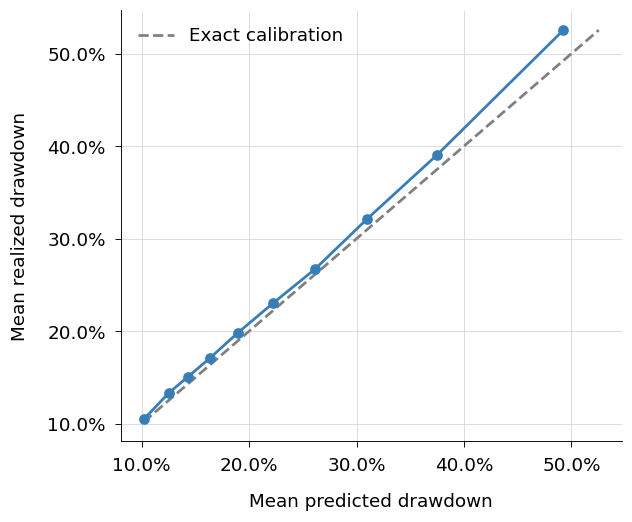

In [4]:
predictions['prediction_decile'] = pd.qcut(
    predictions[prediction].rank(method='first'),
    10,
    labels=False,
) + 1
calibration = (
    predictions.groupby('prediction_decile', as_index=False)
    .agg(
        observations=(target, 'size'),
        mean_prediction=(prediction, 'mean'),
        mean_realized_drawdown=(target, 'mean'),
    )
)
display(
    calibration.style.format(
        {
            'observations': '{:,}',
            'mean_prediction': '{:.2%}',
            'mean_realized_drawdown': '{:.2%}',
        }
    )
)

limits = [
    min(calibration['mean_prediction'].min(), calibration['mean_realized_drawdown'].min()),
    max(calibration['mean_prediction'].max(), calibration['mean_realized_drawdown'].max()),
]
figure, axis = plt.subplots(figsize=(6, 5))
axis.plot(limits, limits, color='gray', linestyle='--', label='Exact calibration')
axis.plot(
    calibration['mean_prediction'],
    calibration['mean_realized_drawdown'],
    marker='o',
    color=COLOR_PALETTE[0],
)
axis.set_xlabel('Mean predicted drawdown')
axis.set_ylabel('Mean realized drawdown')
axis.xaxis.set_major_formatter(PercentFormatter(1.0))
axis.yaxis.set_major_formatter(PercentFormatter(1.0))
axis.legend()
apply_matplotlib_layout(figure)
figure.savefig(paths.figures / "04_01_test_calibration.pdf")
plt.show()

## 5. Fragility Score ordering

The Fragility Score is the within-quarter percentile rank of predicted drawdown. A useful score should order stocks so that higher score deciles subsequently experience larger drawdowns.

,fragility_decile,observations,mean_prediction,mean_realized_drawdown,median_realized_drawdown
0,1,"3,054",10.29%,10.49%,9.21%
1,2,"3,049",12.61%,13.10%,11.50%
2,3,"3,052",14.33%,14.60%,13.08%
3,4,"3,049",16.30%,17.17%,15.25%
4,5,"3,049",18.89%,19.72%,17.61%
5,6,"3,051",22.16%,23.18%,21.08%
6,7,"3,052",26.11%,26.98%,24.50%
7,8,"3,049",30.97%,32.17%,29.44%
8,9,"3,052",37.45%,39.13%,36.76%
9,10,"3,054",49.23%,52.61%,50.16%


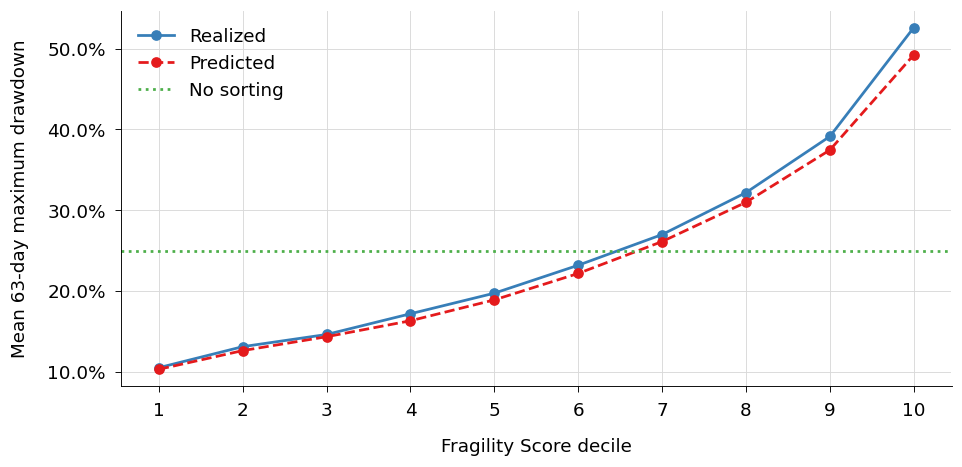

Mean quarterly score-target Spearman: 0.739
Mean quarterly D10-D1 drawdown spread: 42.07%
Quarters with a positive D10-D1 spread: 8 / 8


In [5]:
predictions['fragility_decile'] = np.minimum(
    np.floor(predictions['fragility_score'] / 10).astype(int) + 1,
    10,
)
decile_summary = (
    predictions.groupby('fragility_decile', as_index=False)
    .agg(
        observations=(target, 'size'),
        mean_prediction=(prediction, 'mean'),
        mean_realized_drawdown=(target, 'mean'),
        median_realized_drawdown=(target, 'median'),
    )
)
display(
    decile_summary.style.format(
        {
            'observations': '{:,}',
            'mean_prediction': '{:.2%}',
            'mean_realized_drawdown': '{:.2%}',
            'median_realized_drawdown': '{:.2%}',
        }
    )
)

quarterly_ordering = predictions.groupby('report_period').apply(
    lambda quarter: pd.Series(
        {
            'score_target_spearman': quarter['fragility_score'].corr(
                quarter[target], method='spearman'
            ),
            'decile_10_minus_1': (
                quarter.loc[quarter['fragility_decile'].eq(10), target].mean()
                - quarter.loc[quarter['fragility_decile'].eq(1), target].mean()
            ),
        }
    ),
    include_groups=False,
)

figure, axis = plt.subplots(figsize=SINGLE_PANEL_SIZE)
axis.plot(
    decile_summary['fragility_decile'],
    decile_summary['mean_realized_drawdown'],
    marker='o',
    color=COLOR_PALETTE[0],
    label='Realized',
)
axis.plot(
    decile_summary['fragility_decile'],
    decile_summary['mean_prediction'],
    marker='o',
    linestyle='--',
    color=COLOR_PALETTE[1],
    label='Predicted',
)
axis.axhline(
    predictions[target].mean(),
    color=COLOR_PALETTE[2],
    linestyle=':',
    label='No sorting',
)
axis.set_xlabel('Fragility Score decile')
axis.set_ylabel('Mean 63-day maximum drawdown')
axis.set_xticks(range(1, 11))
axis.yaxis.set_major_formatter(PercentFormatter(1.0))
axis.legend()
apply_matplotlib_layout(figure)
figure.savefig(paths.figures / "04_01_fragility_score_ordering.pdf")
plt.show()

print(
    'Mean quarterly score-target Spearman: '
    f'{quarterly_ordering["score_target_spearman"].mean():.3f}'
)
print(
    'Mean quarterly D10-D1 drawdown spread: '
    f'{quarterly_ordering["decile_10_minus_1"].mean():.2%}'
)
print(
    'Quarters with a positive D10-D1 spread: '
    f'{quarterly_ordering["decile_10_minus_1"].gt(0).sum()} / '
    f'{len(quarterly_ordering)}'
)

## 6. Residual distribution

Residuals equal realized minus predicted drawdown. Positive residuals indicate underprediction; negative residuals indicate overprediction.

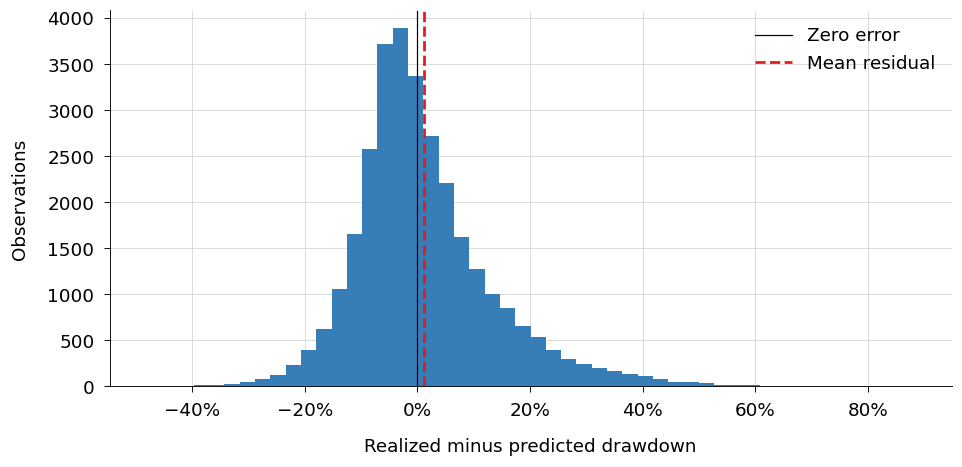

Mean residual: 1.08%
Median residual: -1.07%
Underpredicted observations: 45.67%


In [6]:
residuals = predictions[target] - predictions[prediction]

figure, axis = plt.subplots(figsize=SINGLE_PANEL_SIZE)
axis.hist(residuals, bins=50, color=COLOR_PALETTE[0])
axis.axvline(0, color='black', linewidth=0.8, label='Zero error')
axis.axvline(
    residuals.mean(),
    color=COLOR_PALETTE[1],
    linestyle='--',
    label='Mean residual',
)
axis.set_xlabel('Realized minus predicted drawdown')
axis.set_ylabel('Observations')
axis.xaxis.set_major_formatter(PercentFormatter(1.0))
axis.legend()
apply_matplotlib_layout(figure)
figure.savefig(paths.figures / "04_01_residual_distribution.pdf")
plt.show()

print(f'Mean residual: {residuals.mean():.2%}')
print(f'Median residual: {residuals.median():.2%}')
print(f'Underpredicted observations: {residuals.gt(0).mean():.2%}')

## 7. Error concentration

The following diagnostics test whether average performance conceals larger errors among stocks that subsequently experience severe drawdowns. Realized-drawdown deciles are formed across the full test sample and are used only for retrospective error analysis, not model selection.

,realized_drawdown_decile,observations,mean_realized_drawdown,mae,mean_residual,rmse
0,1,"3,052",5.33%,8.30%,-8.30%,9.68%
1,2,"3,051",9.16%,6.05%,-6.00%,7.62%
2,3,"3,051",11.98%,5.16%,-4.65%,7.36%
3,4,"3,051",14.92%,5.41%,-3.67%,7.68%
4,5,"3,051",18.19%,6.30%,-2.45%,8.45%
5,6,"3,051",22.08%,6.92%,-0.94%,8.76%
6,7,"3,051",26.79%,7.76%,0.68%,9.53%
7,8,"3,051",33.15%,9.21%,3.91%,11.10%
8,9,"3,051",42.44%,11.67%,8.91%,13.99%
9,10,"3,051",65.14%,23.62%,23.33%,27.15%


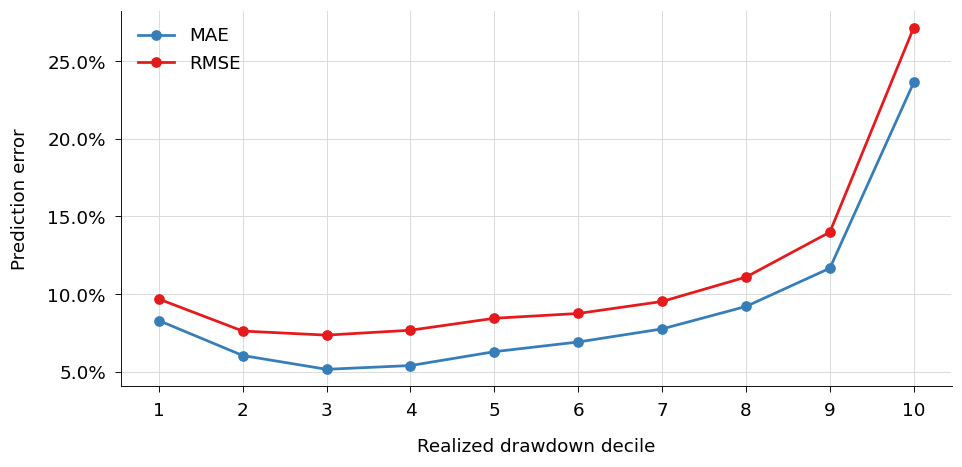

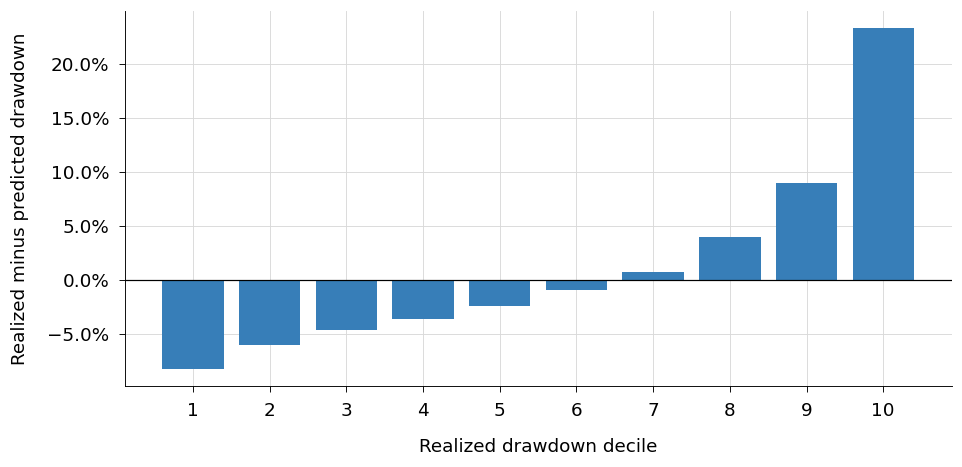

In [7]:
predictions['residual'] = predictions[target] - predictions[prediction]
predictions['absolute_error'] = predictions['residual'].abs()
predictions['squared_error'] = predictions['residual'].pow(2)
predictions['realized_drawdown_decile'] = pd.qcut(
    predictions[target].rank(method='first'),
    10,
    labels=False,
) + 1
error_by_realized_decile = (
    predictions.groupby('realized_drawdown_decile', as_index=False)
    .agg(
        observations=(target, 'size'),
        mean_realized_drawdown=(target, 'mean'),
        mae=('absolute_error', 'mean'),
        mean_squared_error=('squared_error', 'mean'),
        mean_residual=('residual', 'mean'),
    )
)
error_by_realized_decile['rmse'] = np.sqrt(
    error_by_realized_decile.pop('mean_squared_error')
)
display(
    error_by_realized_decile.style.format(
        {
            'observations': '{:,}',
            'mean_realized_drawdown': '{:.2%}',
            'mae': '{:.2%}',
            'rmse': '{:.2%}',
            'mean_residual': '{:.2%}',
        }
    )
)

figure, axis = plt.subplots(figsize=SINGLE_PANEL_SIZE)
axis.plot(
    error_by_realized_decile['realized_drawdown_decile'],
    error_by_realized_decile['mae'],
    marker='o',
    color=COLOR_PALETTE[0],
    label='MAE',
)
axis.plot(
    error_by_realized_decile['realized_drawdown_decile'],
    error_by_realized_decile['rmse'],
    marker='o',
    color=COLOR_PALETTE[1],
    label='RMSE',
)
axis.set_xlabel('Realized drawdown decile')
axis.set_ylabel('Prediction error')
axis.set_xticks(range(1, 11))
axis.yaxis.set_major_formatter(PercentFormatter(1.0))
axis.legend()
apply_matplotlib_layout(figure)
figure.savefig(
    paths.figures / '04_01_error_magnitude_by_realized_decile.pdf'
)
plt.show()

figure, axis = plt.subplots(figsize=SINGLE_PANEL_SIZE)
axis.bar(
    error_by_realized_decile['realized_drawdown_decile'],
    error_by_realized_decile['mean_residual'],
    color=COLOR_PALETTE[0],
)
axis.axhline(0, color='black', linewidth=0.8)
axis.set_xlabel('Realized drawdown decile')
axis.set_ylabel('Realized minus predicted drawdown')
axis.set_xticks(range(1, 11))
axis.yaxis.set_major_formatter(PercentFormatter(1.0))
apply_matplotlib_layout(figure)
figure.savefig(paths.figures / '04_01_mean_residual_by_realized_decile.pdf')
plt.show()

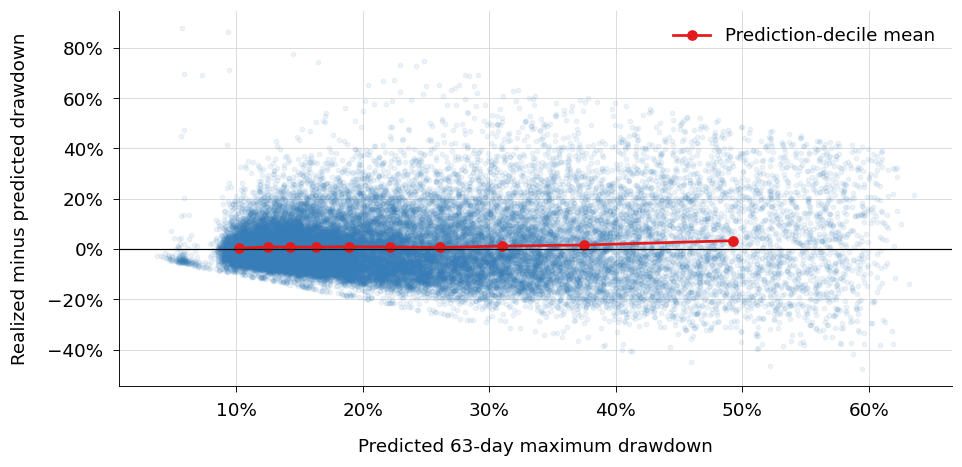

,error_type,report_period,permno,future_max_drawdown_63d,predicted_future_max_drawdown_63d,residual
0,Underprediction,2024-03-31 00:00:00,23232,93.73%,5.70%,+88.03%
1,Underprediction,2024-03-31 00:00:00,23264,95.50%,9.33%,+86.16%
2,Underprediction,2024-09-30 00:00:00,22703,91.91%,14.51%,+77.40%
3,Underprediction,2025-12-31 00:00:00,24092,99.58%,24.85%,+74.74%
4,Underprediction,2024-03-31 00:00:00,22539,90.86%,16.45%,+74.41%
5,Underprediction,2024-06-30 00:00:00,21298,96.07%,22.98%,+73.09%
6,Underprediction,2025-09-30 00:00:00,24469,96.99%,24.22%,+72.78%
7,Underprediction,2024-03-31 00:00:00,23782,80.67%,9.44%,+71.23%
8,Underprediction,2024-09-30 00:00:00,23779,75.43%,5.93%,+69.50%
9,Underprediction,2024-09-30 00:00:00,23049,76.46%,7.32%,+69.14%


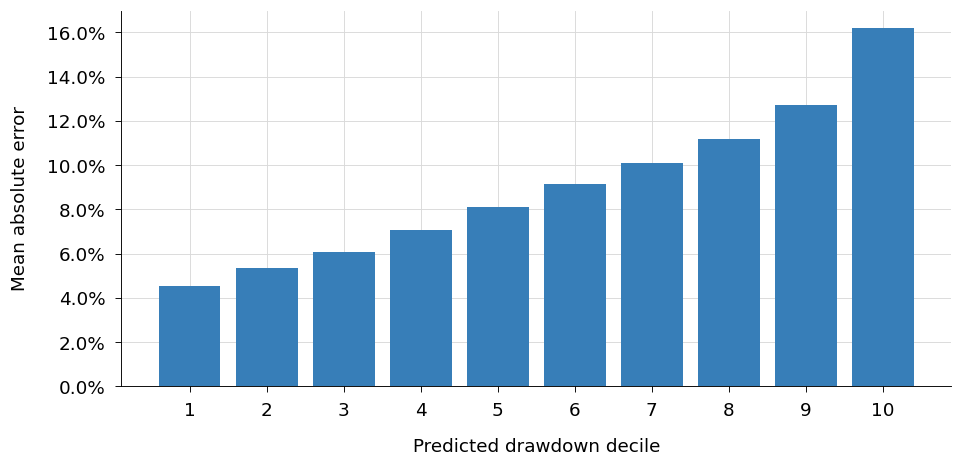

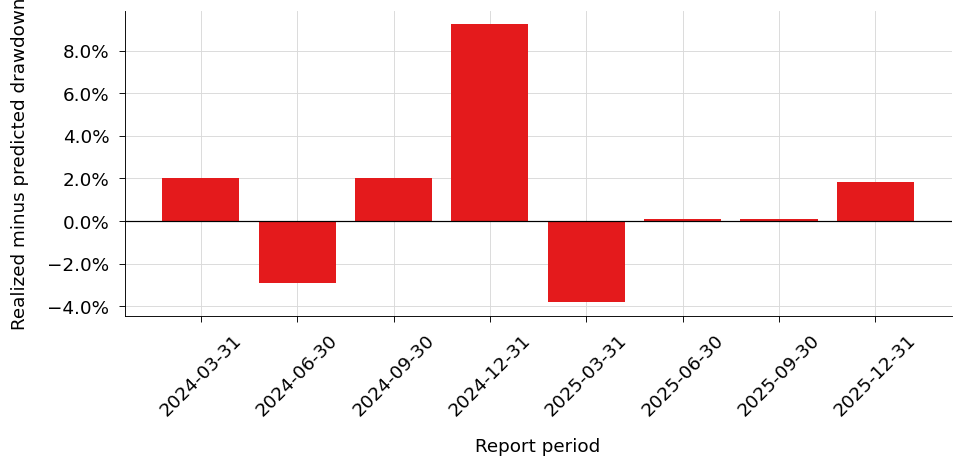

Consecutive-quarter residual pairs: 26,244
Within-stock lag-one residual correlation: -0.029
Quarterly mean residual range: -3.80% to 9.24%


In [8]:
residual_by_prediction_decile = (
    predictions.groupby('prediction_decile', as_index=False)
    .agg(
        mean_prediction=(prediction, 'mean'),
        mean_residual=('residual', 'mean'),
        mean_absolute_error=('absolute_error', 'mean'),
    )
)

figure, axis = plt.subplots(figsize=SINGLE_PANEL_SIZE)
axis.scatter(
    predictions[prediction],
    predictions['residual'],
    s=8,
    alpha=0.08,
    color=COLOR_PALETTE[0],
)
axis.plot(
    residual_by_prediction_decile['mean_prediction'],
    residual_by_prediction_decile['mean_residual'],
    marker='o',
    color=COLOR_PALETTE[1],
    label='Prediction-decile mean',
)
axis.axhline(0, color='black', linewidth=0.8)
axis.set_xlabel('Predicted 63-day maximum drawdown')
axis.set_ylabel('Realized minus predicted drawdown')
axis.xaxis.set_major_formatter(PercentFormatter(1.0))
axis.yaxis.set_major_formatter(PercentFormatter(1.0))
axis.legend()
apply_matplotlib_layout(figure)
figure.savefig(paths.figures / "04_01_residuals_vs_prediction.pdf")
plt.show()

largest_underpredictions = predictions.nlargest(10, 'residual').assign(
    error_type='Underprediction'
)
largest_overpredictions = predictions.nsmallest(10, 'residual').assign(
    error_type='Overprediction'
)
extreme_errors = pd.concat(
    [largest_underpredictions, largest_overpredictions],
    ignore_index=True,
).loc[
    :,
    ['error_type', 'report_period', 'permno', target, prediction, 'residual'],
]
display(
    extreme_errors.style.format(
        {
            target: '{:.2%}',
            prediction: '{:.2%}',
            'residual': '{:+.2%}',
        }
    )
)

quarterly_residuals = (
    predictions.groupby('report_period', as_index=False)
    .agg(
        observations=('residual', 'size'),
        mean_residual=('residual', 'mean'),
        mean_absolute_error=('absolute_error', 'mean'),
    )
)

figure, axis = plt.subplots(figsize=SINGLE_PANEL_SIZE)
axis.bar(
    residual_by_prediction_decile['prediction_decile'],
    residual_by_prediction_decile['mean_absolute_error'],
    color=COLOR_PALETTE[0],
)
axis.set_xlabel('Predicted drawdown decile')
axis.set_ylabel('Mean absolute error')
axis.set_xticks(range(1, 11))
axis.yaxis.set_major_formatter(PercentFormatter(1.0))
apply_matplotlib_layout(figure)
figure.savefig(paths.figures / '04_01_absolute_error_by_prediction_decile.pdf')
plt.show()

figure, axis = plt.subplots(figsize=SINGLE_PANEL_SIZE)
axis.bar(
    quarterly_residuals['report_period'].astype(str),
    quarterly_residuals['mean_residual'],
    color=COLOR_PALETTE[1],
)
axis.axhline(0, color='black', linewidth=0.8)
axis.set_xlabel('Report period')
axis.set_ylabel('Realized minus predicted drawdown')
axis.tick_params(axis='x', rotation=45)
axis.yaxis.set_major_formatter(PercentFormatter(1.0))
apply_matplotlib_layout(figure)
figure.savefig(paths.figures / '04_01_mean_residual_by_test_quarter.pdf')
plt.show()

ordered_residuals = predictions.sort_values(
    ['permno', 'report_period']
).copy()
report_dates = pd.to_datetime(ordered_residuals['report_period'])
ordered_residuals['quarter_number'] = (
    report_dates.dt.year * 4 + report_dates.dt.quarter
)
ordered_residuals['previous_residual'] = (
    ordered_residuals.groupby('permno')['residual'].shift()
)
ordered_residuals['previous_quarter_number'] = (
    ordered_residuals.groupby('permno')['quarter_number'].shift()
)
consecutive_pairs = ordered_residuals.loc[
    ordered_residuals['quarter_number'].eq(
        ordered_residuals['previous_quarter_number'] + 1
    )
]
lag_one_residual_correlation = consecutive_pairs['residual'].corr(
    consecutive_pairs['previous_residual']
)

print(
    'Consecutive-quarter residual pairs: '
    f'{len(consecutive_pairs):,}'
)
print(
    'Within-stock lag-one residual correlation: '
    f'{lag_one_residual_correlation:.3f}'
)
print(
    'Quarterly mean residual range: '
    f'{quarterly_residuals["mean_residual"].min():.2%} to '
    f'{quarterly_residuals["mean_residual"].max():.2%}'
)

## 8. Interpretation

- **Validation selects the augmented XGBoost model.** After redundant predictors are removed, `xgboost_augmented` has validation MAE of 0.094249, 0.001124 below the next-best candidate, `xgboost_market`. The retained ownership variables therefore add a small validation improvement beyond the seven market predictors.
- **Validation-only tuning provides a modest further gain.** The selected model uses 179 trees, depth 3, minimum child weight 5, and subsampling of 0.8. Tuning lowers validation MAE by 0.000651, or 0.69%, relative to the corresponding untuned candidate.
- **Held-out predictive performance is strong.** Across 30,511 observations in eight test quarters, the selected model achieves MAE of 0.0904, RMSE of 0.1249, R-squared of 0.504, and mean quarterly Spearman correlation of 0.739.
- **The model clearly beats the no-information benchmark.** The historical-mean forecast has test MAE of 0.1302 and negative R-squared of -0.053. The selected model reduces MAE by about 30.6%, while its rank correlation is well above the zero expected under random ordering.
- **The Fragility Score retains clear economic ordering.** The mean quarterly realized-drawdown spread between Deciles 10 and 1 is 42.07 percentage points and is positive in all eight test quarters.
- **Residual diagnostics remain mixed but acceptable.** The mean residual is +1.08 percentage points, the median is -1.07 percentage points, and the within-stock lag-one residual correlation is -0.029. Errors therefore show modest average underprediction, temporal variation in calibration, and no meaningful consecutive-quarter persistence.

The validation rule now supports the augmented XGBoost specification as the primary tabular model. This change follows from the pruned feature set and validation results; the held-out test sample was not used to choose the model or its tuning parameters.